In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import datetime
from dataclasses import dataclass
from tqdm import tqdm

# Data parsing

In [2]:
@dataclass
class RouteData:
    timestamp: datetime
    car_id: str
    car_type: str
    gate_name: str

data: list[RouteData] = []

with open('../data/sensors.csv', 'r') as file:
    lines = file.readlines()[1:]

    for line in tqdm(lines):
        timestamp, car_id, car_type, gate_name = line.strip().split(',')

        timestamp = datetime.strptime(timestamp, '%Y-%m-%d %H:%M:%S')

        data.append(RouteData(timestamp, car_id, car_type, gate_name))

data = sorted(data, key=lambda x: x.timestamp)

100%|██████████| 171477/171477 [00:01<00:00, 151289.82it/s]


# Grouping by `car_id`

In [3]:
routes = {}

for point in tqdm(data):
    if point.car_id not in routes:
        routes[point.car_id] = []
    
    routes[point.car_id].append(point)

100%|██████████| 171477/171477 [00:00<00:00, 3097017.93it/s]


# Route points distribution

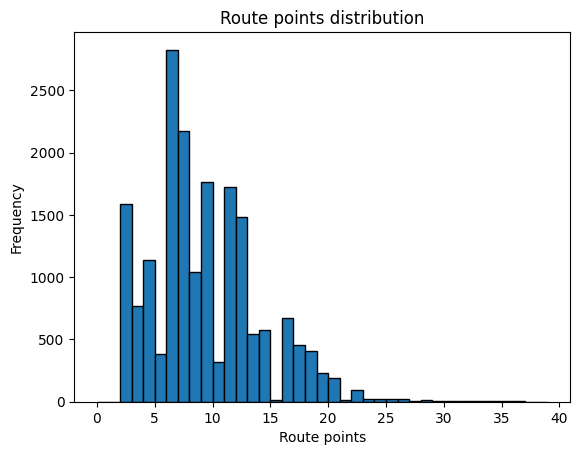

In [4]:
route_lengths = [len(route) for route in routes.values()]

plt.hist(route_lengths, bins=range(40), edgecolor='black')
plt.title('Route points distribution')
plt.xlabel('Route points')
plt.ylabel('Frequency')
plt.show()

# No camping routes stats

In [5]:
routes_no_camping = {car_id: route for car_id, route in routes.items() if not any(point.gate_name.startswith('camping') for point in route)}

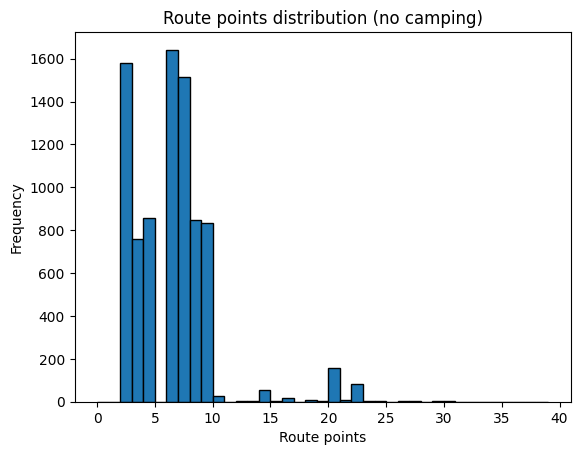

In [6]:
plt.hist([len(route) for route in routes_no_camping.values()], bins=range(40), edgecolor='black')
plt.title('Route points distribution (no camping)')
plt.xlabel('Route points')
plt.ylabel('Frequency')
plt.show()

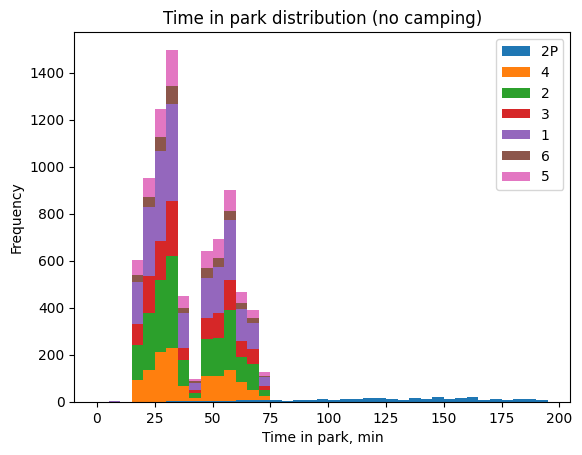

In [7]:
car_types = set(x.car_type for x in data)
hist_data = [[(route[-1].timestamp - route[0].timestamp).seconds / 60 for route in routes_no_camping.values() if route[0].car_type == car_type] for car_type in car_types]

plt.hist(hist_data, stacked=True, bins=range(0, 200, 5), label=list(car_types))
plt.title('Time in park distribution (no camping)')
plt.xlabel('Time in park, min')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [38]:
routes_short = {route[0].car_id: [point for point in route if not point.gate_name.startswith(('general', 'gate'))] for route in routes_no_camping.values() if (route[-1].timestamp - route[0].timestamp).seconds / 60 < 25 and route[0].car_type != '2P' }

nodes = list(set(point.gate_name for route in routes_short.values() for point in route))
node_idx = {node: i for i, node in enumerate(nodes)}
source = [node_idx.get(point.gate_name) for route in routes_short.values() for point in route[:-1]]
target = [node_idx.get(point.gate_name) for route in routes_short.values() for point in route[1:]]
values = {}

for edge in zip(source, target):
    if (edge[0] is None or edge[1] is None): 
        continue

    if edge not in values:
        values[edge] = 1
    else:
        values[edge] += 1

source = []
target = []
values_raw = []

for (s, t), v in values.items():
    source.append(s)
    target.append(t)
    values_raw.append(v)

fig = go.Figure(go.Sankey(
    node=dict(
        label=nodes
    ),
    link=dict(
        source=source,
        target=target,
        value=values_raw
    )
))
fig.update_layout(title='Quick routes (<25 min)')
fig.show()

In [39]:
routes_long = {route[0].car_id: [point for point in route if not point.gate_name.startswith(('general', 'gate'))] for route in routes_no_camping.values() if (route[-1].timestamp - route[0].timestamp).seconds / 60 >= 25 and route[0].car_type != '2P' }

nodes = list(set(point.gate_name for route in routes_long.values() for point in route))
node_idx = {node: i for i, node in enumerate(nodes)}
source = [node_idx.get(point.gate_name) for route in routes_long.values() for point in route[:-1]]
target = [node_idx.get(point.gate_name) for route in routes_long.values() for point in route[1:]]
values = {}

for edge in zip(source, target):
    if (edge[0] is None or edge[1] is None): 
        continue

    if edge not in values:
        values[edge] = 1
    else:
        values[edge] += 1

source = []
target = []
values_raw = []

for (s, t), v in values.items():
    source.append(s)
    target.append(t)
    values_raw.append(v)

fig = go.Figure(go.Sankey(
    node=dict(
        label=nodes
    ),
    link=dict(
        source=source,
        target=target,
        value=values_raw
    )
))
fig.update_layout(title='Long routes (>25 min)')
fig.show()